# EDA - Product Performance & Profitability Analysis
**Program:** Simulasi Industri Junior Data Analyst - Topik 7 | **Analis:** Siswa 3 | **Input:** `03_Clean_Dataset.csv` (5.000 order x 20 kolom)

**Tujuan EDA:** menjawab business question pada Project Charter melalui analisis univariate, bivariate, tren, dan segmentasi.

| No | Business Question (dari charter) | Bagian |
|---|---|---|
| BQ1 | Kategori mana yang menyumbang revenue bersih dan volume terbesar? | B |
| BQ2 | Berapa nilai penjualan hilang akibat diskon, dan pada level berapa diskon tidak sebanding dengan tambahan volume? | C |
| BQ3 | Bagaimana estimasi profit dan margin pada beberapa skenario rasio biaya? | D |
| BQ4 | Apakah harga/diskon tinggi berkaitan dengan rating dan volume? | C, E |
| BQ5 | Apakah lama pengiriman berkaitan dengan rating? | E |

> Catatan: data tidak memiliki biaya produk, sehingga profit hanya **estimasi berbasis skenario** (biaya = rasio x gross sales).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=0.95)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
pd.set_option('display.width', 220)

df = pd.read_csv('03_Clean_Dataset.csv', parse_dates=['order_date'])
print('Ukuran data :', df.shape)
print('Periode     :', df.order_date.min().date(), 's.d.', df.order_date.max().date())
print()
print(df.dtypes.to_string())

Ukuran data : (5000, 20)
Periode     : 2022-01-01 s.d. 2035-09-09

order_id                       int64
order_date            datetime64[us]
customer_id                    int64
product_category                 str
region                           str
quantity                       int64
unit_price                   float64
discount                     float64
payment_method                   str
delivery_days                  int64
customer_rating              float64
revenue                      float64
year                           int64
month                          int64
year_month                       str
gross_sales                  float64
discount_value               float64
discount_band                    str
is_future_date                 int64
is_revenue_outlier             int64


In [2]:
CATS = ['Electronics', 'Clothing', 'Home', 'Beauty']
COL  = {'Electronics': '#1F3864', 'Clothing': '#2E75B6', 'Home': '#ED7D31', 'Beauty': '#70AD47'}
BAND = ['0-5%', '>5-10%', '>10-15%', '>15-20%', '>20-25%', '>25-30%', '>30-35%']
df['product_category'] = pd.Categorical(df.product_category, CATS, ordered=True)
df['discount_band']    = pd.Categorical(df.discount_band, BAND, ordered=True)

TOTAL_NET, TOTAL_GROSS = df.revenue.sum(), df.gross_sales.sum()
print(f'Total Net Revenue  : {TOTAL_NET:,.2f}')
print(f'Total Gross Sales  : {TOTAL_GROSS:,.2f}')
print(f'Total Discount     : {TOTAL_GROSS-TOTAL_NET:,.2f}  ({(TOTAL_GROSS-TOTAL_NET)/TOTAL_GROSS:.1%} dari gross)')
print(f'Orders / Customers : {len(df):,} / {df.customer_id.nunique():,}')

Total Net Revenue  : 5,109,775.74
Total Gross Sales  : 6,240,021.96
Total Discount     : 1,130,246.22  (18.1% dari gross)
Orders / Customers : 5,000 / 989


## A. Analisis Univariate
Distribusi variabel numerik, komposisi kategori, dan statistik deskriptif.

In [3]:
num = ['quantity', 'unit_price', 'discount', 'delivery_days', 'customer_rating', 'revenue']
desc = df[num].describe().T
desc['skew'] = df[num].skew()
print(desc.to_string())

                    count      mean     std    min     25%     50%       75%       max   skew
quantity        5,000.000     4.045   2.020  1.000   2.000   4.000     6.000     7.000 -0.021
unit_price      5,000.000   308.419 169.259 15.150 161.895 309.890   455.558   599.960 -0.011
discount        5,000.000     0.180   0.101  0.000   0.090   0.180     0.270     0.350 -0.067
delivery_days   5,000.000     6.119   3.153  1.000   3.000   6.000     9.000    11.000 -0.056
customer_rating 5,000.000     2.974   1.158  1.000   2.000   3.000     4.000     5.000  0.035
revenue         5,000.000 1,021.955 825.584 11.210 354.527 796.650 1,515.690 4,119.330  1.002


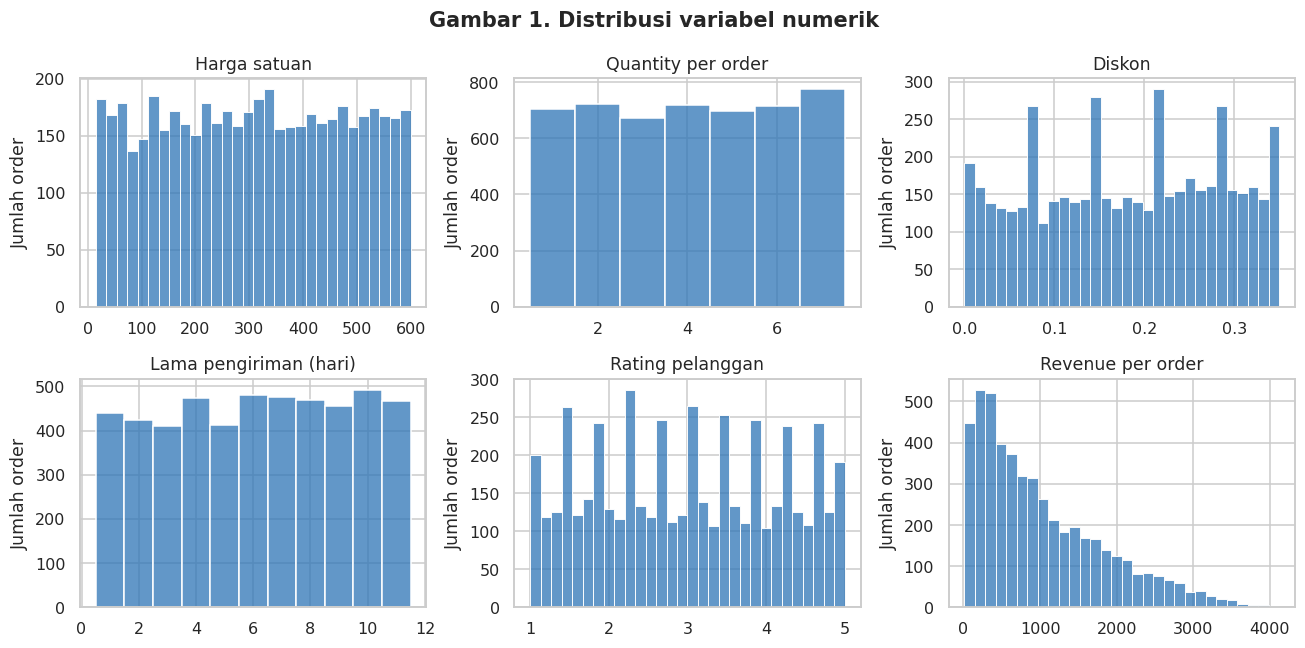

In [4]:
# FIG: fig01_distribusi
cols   = ['unit_price', 'quantity', 'discount', 'delivery_days', 'customer_rating', 'revenue']
titles = ['Harga satuan', 'Quantity per order', 'Diskon', 'Lama pengiriman (hari)', 'Rating pelanggan', 'Revenue per order']
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, c, t in zip(axes.ravel(), cols, titles):
    kw = dict(discrete=True) if c in ['quantity', 'delivery_days'] else dict(bins=30)
    sns.histplot(df[c], ax=ax, color='#2E75B6', **kw)
    ax.set_title(t); ax.set_xlabel(''); ax.set_ylabel('Jumlah order')
fig.suptitle('Gambar 1. Distribusi variabel numerik', fontweight='bold')
fig.tight_layout(); plt.show()

region
West     1289
North    1276
East     1227
South    1208


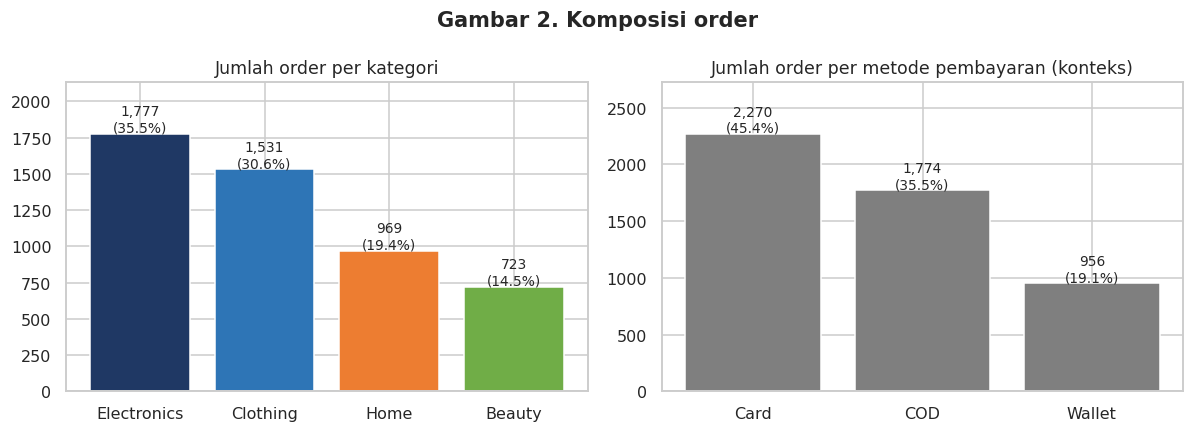

In [5]:
# FIG: fig02_komposisi_order
cnt = df.product_category.value_counts().reindex(CATS)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(cnt.index, cnt.values, color=[COL[c] for c in cnt.index])
for i, v in enumerate(cnt.values):
    axes[0].text(i, v + 15, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=9)
axes[0].set_title('Jumlah order per kategori'); axes[0].set_ylim(0, cnt.max() * 1.2)
pay = df.payment_method.value_counts()
axes[1].bar(pay.index, pay.values, color='#7F7F7F')
for i, v in enumerate(pay.values):
    axes[1].text(i, v + 15, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=9)
axes[1].set_title('Jumlah order per metode pembayaran (konteks)'); axes[1].set_ylim(0, pay.max() * 1.2)
fig.suptitle('Gambar 2. Komposisi order', fontweight='bold'); fig.tight_layout(); plt.show()
print(df.region.value_counts().to_string())

## B. Performa Kategori Produk (BQ1)
KPI sesuai charter: Net Revenue, Gross Sales, Discount Value/Rate, Units, Orders, Avg Selling Price, Revenue Contribution %.

In [6]:
g = df.groupby('product_category', observed=True).agg(
    orders=('order_id', 'count'), customers=('customer_id', 'nunique'), units=('quantity', 'sum'),
    gross=('gross_sales', 'sum'), net=('revenue', 'sum'), disc_value=('discount_value', 'sum'),
    avg_unit_price=('unit_price', 'mean'), aov=('revenue', 'mean'),
    rating=('customer_rating', 'mean'), delivery=('delivery_days', 'mean'))
g['discount_rate'] = g.disc_value / g.gross
g['asp']           = g.net / g.units          # Avg Selling Price = Net Revenue / Units
g['contribution']  = g.net / TOTAL_NET
g['order_share']   = g.orders / len(df)
print(g.to_string())
print('\nCatatan: customers dihitung per kategori (customer bisa membeli > 1 kategori).')

                  orders  customers  units         gross           net  disc_value  avg_unit_price       aov  rating  delivery  discount_rate     asp  contribution  order_share
product_category                                                                                                                                                                
Electronics         1777        820   7109 2,223,312.570 1,829,899.220 393,413.350         314.903 1,029.769   2.951     6.070          0.177 257.406         0.358        0.355
Clothing            1531        784   6171 1,887,131.500 1,531,931.720 355,199.780         304.011 1,000.609   3.005     6.119          0.188 248.247         0.300        0.306
Home                 969        597   3949 1,196,217.970   982,083.920 214,134.050         306.258 1,013.502   2.941     6.146          0.179 248.692         0.192        0.194
Beauty               723        514   2995   933,359.920   765,860.880 167,499.040         304.713 1,059.282   3.00

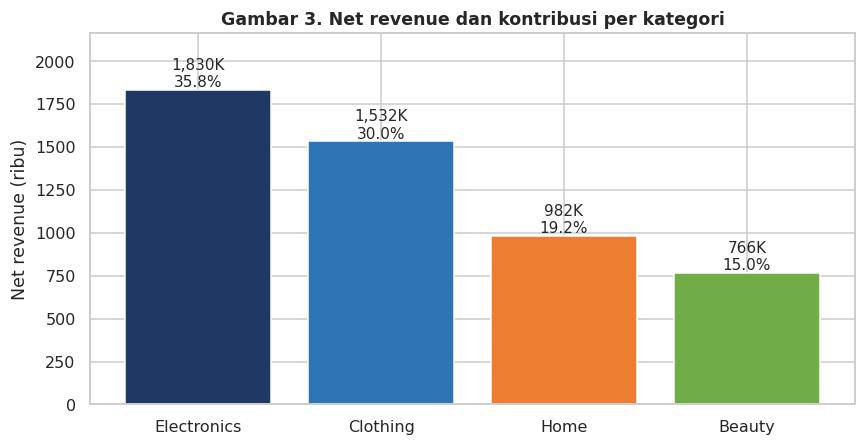

In [7]:
# FIG: fig03_net_revenue
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(g.index, g.net / 1e3, color=[COL[c] for c in g.index])
for i, (v, s) in enumerate(zip(g.net / 1e3, g.contribution)):
    ax.text(i, v + 20, f'{v:,.0f}K\n{s:.1%}', ha='center', fontsize=10)
ax.set_ylabel('Net revenue (ribu)'); ax.set_ylim(0, g.net.max() / 1e3 * 1.18)
ax.set_title('Gambar 3. Net revenue dan kontribusi per kategori', fontweight='bold')
plt.tight_layout(); plt.show()

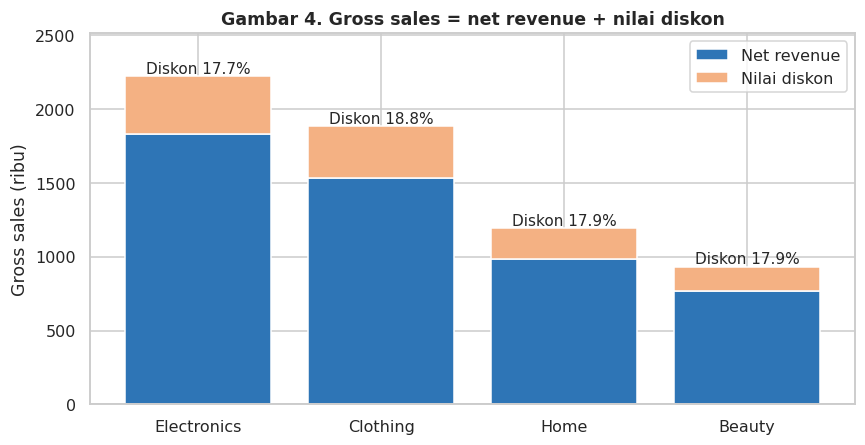

In [8]:
# FIG: fig04_gross_vs_net
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(g.index, g.net / 1e3, color='#2E75B6', label='Net revenue')
ax.bar(g.index, g.disc_value / 1e3, bottom=g.net / 1e3, color='#F4B183', label='Nilai diskon')
for i, (n, d, r) in enumerate(zip(g.net / 1e3, g.disc_value / 1e3, g.discount_rate)):
    ax.text(i, n + d + 20, f'Diskon {r:.1%}', ha='center', fontsize=10)
ax.set_ylabel('Gross sales (ribu)'); ax.set_ylim(0, (g.net + g.disc_value).max() / 1e3 * 1.13)
ax.legend(loc='upper right'); ax.set_title('Gambar 4. Gross sales = net revenue + nilai diskon', fontweight='bold')
plt.tight_layout(); plt.show()

ANOVA unit_price antar kategori : F=1.38, p=0.246
ANOVA revenue/order antar kategori: F=0.92, p=0.430


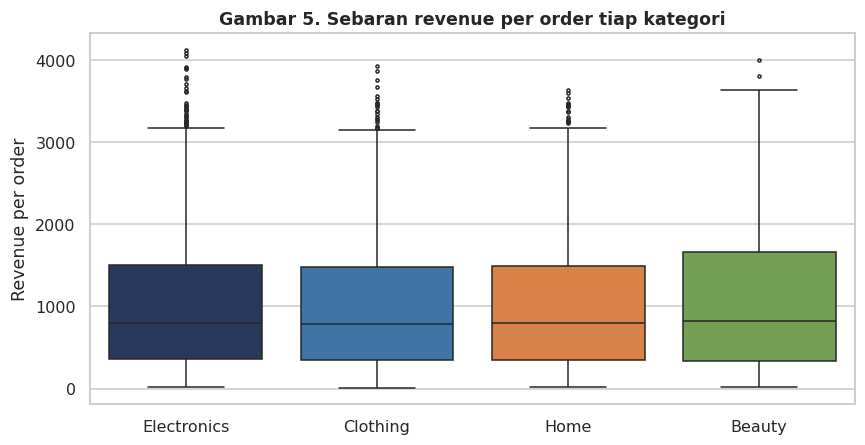

In [9]:
# FIG: fig05_boxplot_revenue
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.boxplot(data=df, x='product_category', y='revenue', order=CATS, palette=COL, ax=ax, fliersize=2)
ax.set_xlabel(''); ax.set_ylabel('Revenue per order')
ax.set_title('Gambar 5. Sebaran revenue per order tiap kategori', fontweight='bold')
plt.tight_layout(); plt.show()
f_p, p_p = stats.f_oneway(*[x.unit_price for _, x in df.groupby('product_category', observed=True)])
f_r, p_r = stats.f_oneway(*[x.revenue for _, x in df.groupby('product_category', observed=True)])
print(f'ANOVA unit_price antar kategori : F={f_p:.2f}, p={p_p:.3f}')
print(f'ANOVA revenue/order antar kategori: F={f_r:.2f}, p={p_r:.3f}')

## C. Dampak Diskon (BQ2 dan BQ4)
Diskon dikelompokkan per 5 poin persen. Pertanyaan: apakah diskon lebih besar menambah volume (quantity) atau rating?

In [10]:
b = df.groupby('discount_band', observed=True).agg(
    orders=('order_id', 'count'), avg_qty=('quantity', 'mean'), avg_gross=('gross_sales', 'mean'),
    aov=('revenue', 'mean'), rating=('customer_rating', 'mean'), disc_value=('discount_value', 'sum'))
b['share_disc_value'] = b.disc_value / b.disc_value.sum()
print(b.to_string())
print(f"\nAOV turun dari {b.aov.iloc[0]:,.0f} (0-5%) ke {b.aov.iloc[-1]:,.0f} (>30-35%): {b.aov.iloc[-1]/b.aov.iloc[0]-1:.1%}")

               orders  avg_qty  avg_gross       aov  rating  disc_value  share_disc_value
discount_band                                                                            
0-5%              748    4.068  1,242.003 1,208.250   2.954  25,247.060             0.022
>5-10%            653    3.953  1,198.465 1,103.574   2.966  61,963.860             0.055
>10-15%           709    4.104  1,251.932 1,088.790   2.971 115,667.750             0.102
>15-20%           692    4.030  1,251.911 1,026.366   2.942 156,077.450             0.138
>20-25%           763    4.075  1,273.225   979.440   2.976 224,158.190             0.198
>25-30%           739    4.070  1,260.465   907.280   2.966 261,003.510             0.231
>30-35%           696    4.000  1,252.169   841.065   3.044 286,128.400             0.253

AOV turun dari 1,208 (0-5%) ke 841 (>30-35%): -30.4%


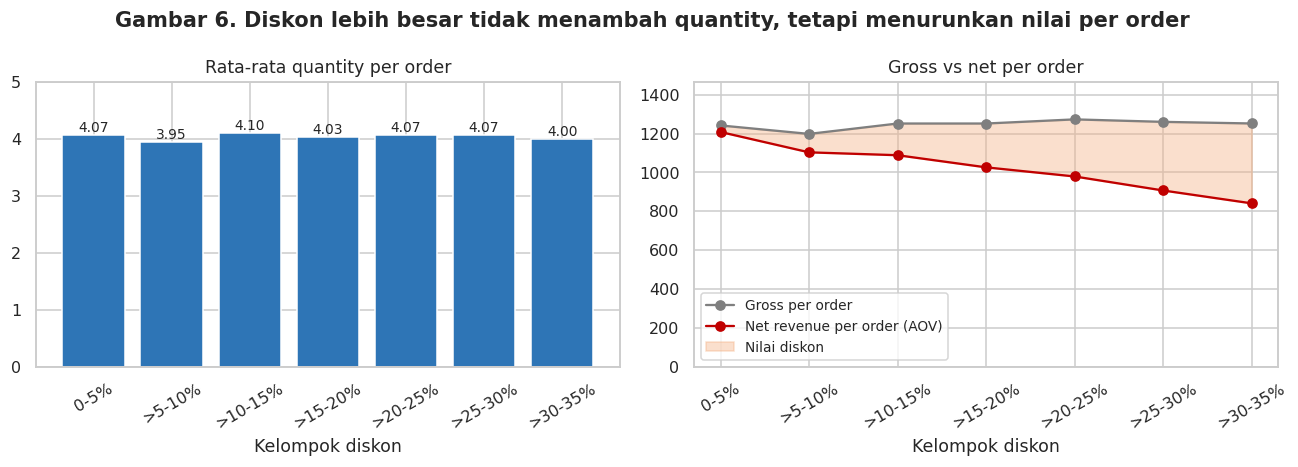

In [11]:
# FIG: fig06_diskon_qty_aov
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].bar(b.index, b.avg_qty, color='#2E75B6')
for i, v in enumerate(b.avg_qty): axes[0].text(i, v + 0.06, f'{v:.2f}', ha='center', fontsize=9)
axes[0].set_ylim(0, 5); axes[0].set_title('Rata-rata quantity per order'); axes[0].set_xlabel('Kelompok diskon')
axes[0].tick_params(axis='x', rotation=30)
axes[1].plot(b.index.astype(str), b.avg_gross, marker='o', color='#7F7F7F', label='Gross per order')
axes[1].plot(b.index.astype(str), b.aov, marker='o', color='#C00000', label='Net revenue per order (AOV)')
axes[1].fill_between(range(len(b)), b.aov, b.avg_gross, color='#F4B183', alpha=.4, label='Nilai diskon')
axes[1].set_ylim(0, b.avg_gross.max() * 1.15); axes[1].legend(loc='lower left', fontsize=9)
axes[1].set_title('Gross vs net per order'); axes[1].set_xlabel('Kelompok diskon'); axes[1].tick_params(axis='x', rotation=30)
fig.suptitle('Gambar 6. Diskon lebih besar tidak menambah quantity, tetapi menurunkan nilai per order', fontweight='bold')
fig.tight_layout(); plt.show()

In [12]:
rows = []
for c, x in list(df.groupby('product_category', observed=True)) + [('ALL', df)]:
    r1, p1 = stats.pearsonr(x.discount, x.quantity)
    r2, p2 = stats.pearsonr(x.discount, x.customer_rating)
    r3, p3 = stats.pearsonr(x.unit_price, x.quantity)
    r4, p4 = stats.pearsonr(x.unit_price, x.customer_rating)
    rows.append([c, r1, p1, r2, p2, r3, p3, r4, p4])
corr_tbl = pd.DataFrame(rows, columns=['category', 'r_disc_qty', 'p1', 'r_disc_rating', 'p2', 'r_price_qty', 'p3', 'r_price_rating', 'p4'])
print(corr_tbl.to_string(index=False))
print('\np > 0,05 = tidak signifikan secara statistik.')

   category  r_disc_qty    p1  r_disc_rating    p2  r_price_qty    p3  r_price_rating    p4
Electronics      -0.026 0.278          0.009 0.711       -0.025 0.289          -0.025 0.298
   Clothing       0.030 0.237          0.026 0.301        0.021 0.408           0.003 0.901
       Home       0.004 0.896          0.033 0.307       -0.040 0.213           0.060 0.064
     Beauty      -0.038 0.311         -0.041 0.270        0.084 0.023           0.010 0.781
        ALL      -0.004 0.761          0.013 0.366        0.001 0.916           0.005 0.722

p > 0,05 = tidak signifikan secara statistik.


## D. Estimasi Profitabilitas (BQ3)
Karena tidak ada data biaya, dipakai tiga skenario: biaya = 60%, 70%, 80% dari **gross sales** (harga sebelum diskon).

- Estimated Gross Profit = Net Revenue - (rasio biaya x Gross Sales)
- Margin = Profit / Net Revenue
- Titik impas diskon = 1 - rasio biaya. Order dengan diskon di atas titik impas **merugi**.

> Rasio biaya diasumsikan sama untuk semua kategori, sehingga perbedaan margin antar kategori hanya berasal dari perbedaan diskon.

In [13]:
COST = [0.60, 0.70, 0.80]
rows = []
for cat, x in list(df.groupby('product_category', observed=True)) + [('TOTAL', df)]:
    for cr in COST:
        be = 1 - cr
        profit = x.revenue.sum() - cr * x.gross_sales.sum()
        loss = x[x.discount > be + 1e-9]
        rows.append(dict(category=cat, cost_ratio=cr, est_profit=profit, margin=profit / x.revenue.sum(),
                         break_even_disc=be, orders_above_be=len(loss) / len(x), loss_orders=len(loss),
                         loss_amount=(loss.revenue - cr * loss.gross_sales).sum(),
                         rev_from_loss_orders=loss.revenue.sum() / x.revenue.sum()))
sc = pd.DataFrame(rows)
print(sc.to_string(index=False))

   category  cost_ratio    est_profit  margin  break_even_disc  orders_above_be  loss_orders  loss_amount  rev_from_loss_orders
Electronics       0.600   495,911.678   0.271            0.400            0.000            0        0.000                 0.000
Electronics       0.700   273,580.421   0.150            0.300            0.136          241   -8,588.286                 0.111
Electronics       0.800    51,249.164   0.028            0.200            0.418          743  -74,004.216                 0.370
   Clothing       0.600   399,652.820   0.261            0.400            0.000            0        0.000                 0.000
   Clothing       0.700   210,939.670   0.138            0.300            0.137          209   -7,605.704                 0.113
   Clothing       0.800    22,226.520   0.015            0.200            0.465          712  -70,117.940                 0.434
       Home       0.600   264,353.138   0.269            0.400            0.000            0        0.00

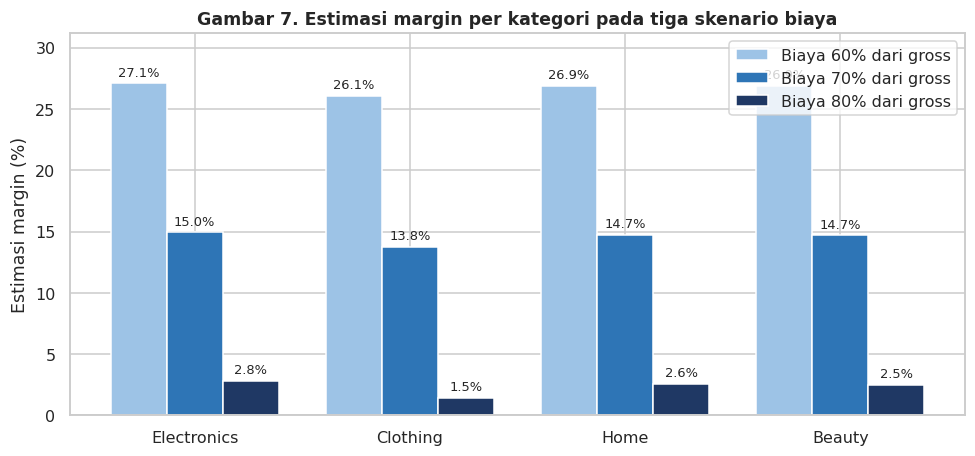

In [14]:
# FIG: fig07_margin_skenario
piv = sc[sc.category != 'TOTAL'].pivot(index='category', columns='cost_ratio', values='margin').reindex(CATS)
fig, ax = plt.subplots(figsize=(9, 4.3))
w = 0.26; colors = ['#9DC3E6', '#2E75B6', '#1F3864']
for j, cr in enumerate(COST):
    xs = np.arange(len(CATS)) + (j - 1) * w
    ax.bar(xs, piv[cr] * 100, width=w, color=colors[j], label=f'Biaya {cr:.0%} dari gross')
    for x_, v in zip(xs, piv[cr] * 100): ax.text(x_, v + 0.6, f'{v:.1f}%', ha='center', fontsize=8.5)
ax.set_xticks(range(len(CATS))); ax.set_xticklabels(CATS); ax.set_ylabel('Estimasi margin (%)')
ax.set_ylim(0, piv.max().max() * 100 * 1.15); ax.legend()
ax.set_title('Gambar 7. Estimasi margin per kategori pada tiga skenario biaya', fontweight='bold')
plt.tight_layout(); plt.show()

Pada biaya 60% titik impas = 40% diskon, sedangkan diskon maksimum data = 35% -> 0 order merugi.


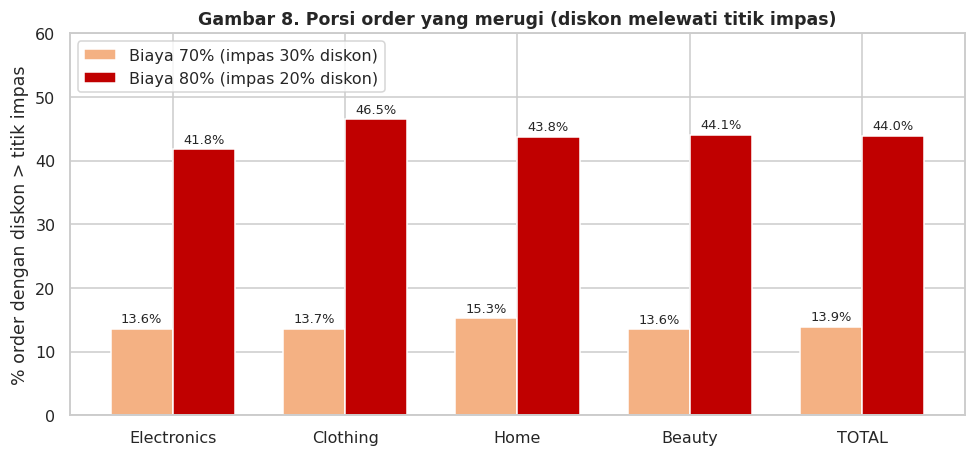

In [15]:
# FIG: fig08_order_di_atas_titik_impas
p2 = sc[sc.cost_ratio.isin([0.70, 0.80])].pivot(index='category', columns='cost_ratio', values='orders_above_be').reindex(CATS + ['TOTAL'])
fig, ax = plt.subplots(figsize=(9, 4.3))
w = 0.36
for j, (cr, colr) in enumerate([(0.70, '#F4B183'), (0.80, '#C00000')]):
    xs = np.arange(len(p2)) + (j - 0.5) * w
    ax.bar(xs, p2[cr] * 100, width=w, color=colr, label=f'Biaya {cr:.0%} (impas {1-cr:.0%} diskon)')
    for x_, v in zip(xs, p2[cr] * 100): ax.text(x_, v + 1, f'{v:.1f}%', ha='center', fontsize=8.5)
ax.set_xticks(range(len(p2))); ax.set_xticklabels(p2.index); ax.set_ylabel('% order dengan diskon > titik impas')
ax.set_ylim(0, 60); ax.legend(loc='upper left')
ax.set_title('Gambar 8. Porsi order yang merugi (diskon melewati titik impas)', fontweight='bold')
plt.tight_layout(); plt.show()
print('Pada biaya 60% titik impas = 40% diskon, sedangkan diskon maksimum data = 35% -> 0 order merugi.')

## E. Hubungan Antarvariabel: Harga, Diskon, Rating, Pengiriman (BQ4 dan BQ5)

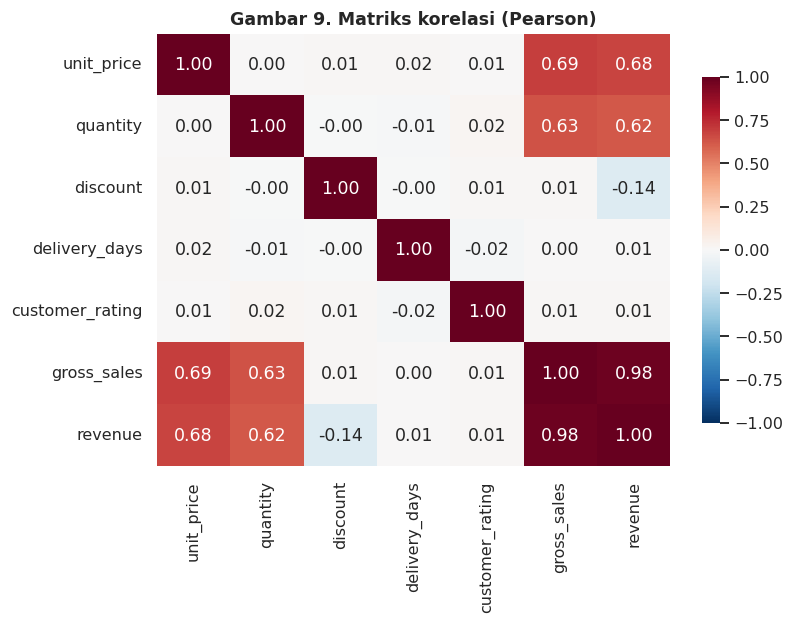

In [16]:
# FIG: fig09_korelasi
cm = df[['unit_price', 'quantity', 'discount', 'delivery_days', 'customer_rating', 'gross_sales', 'revenue']].corr()
fig, ax = plt.subplots(figsize=(7.5, 5.8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0, ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Gambar 9. Matriks korelasi (Pearson)', fontweight='bold'); plt.tight_layout(); plt.show()

             rating   qty     n
price_band                     
Q1 termurah   2.936 4.043  1000
Q2            2.962 4.054  1000
Q3            3.041 4.034  1000
Q4            2.992 4.057  1000
Q5 termahal   2.939 4.036  1000


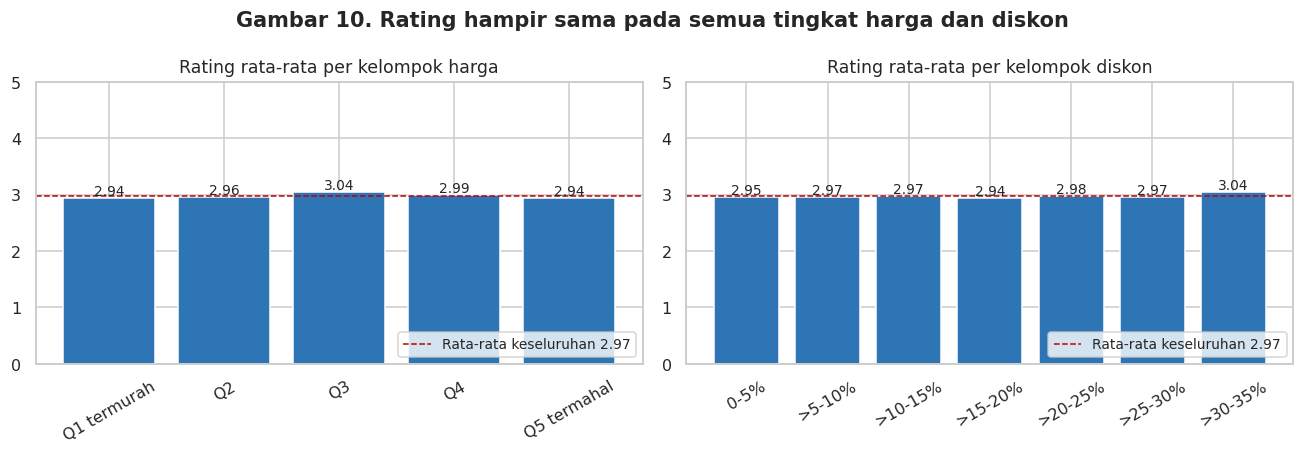

In [17]:
# FIG: fig10_rating_harga_diskon
df['price_band'] = pd.qcut(df.unit_price, 5, labels=['Q1 termurah', 'Q2', 'Q3', 'Q4', 'Q5 termahal'])
r_price = df.groupby('price_band', observed=True).agg(rating=('customer_rating', 'mean'), qty=('quantity', 'mean'), n=('order_id', 'count'))
r_disc  = df.groupby('discount_band', observed=True).agg(rating=('customer_rating', 'mean'), n=('order_id', 'count'))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, s, ttl in [(axes[0], r_price, 'Rating rata-rata per kelompok harga'), (axes[1], r_disc, 'Rating rata-rata per kelompok diskon')]:
    ax.bar(s.index.astype(str), s.rating, color='#2E75B6')
    for i, v in enumerate(s.rating): ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
    ax.axhline(df.customer_rating.mean(), ls='--', color='#C00000', lw=1, label=f'Rata-rata keseluruhan {df.customer_rating.mean():.2f}')
    ax.set_ylim(0, 5); ax.set_title(ttl); ax.tick_params(axis='x', rotation=30); ax.legend(loc='lower right', fontsize=9)
fig.suptitle('Gambar 10. Rating hampir sama pada semua tingkat harga dan diskon', fontweight='bold')
fig.tight_layout(); plt.show()
print(r_price.to_string())

   category  r_delivery_rating  p_value
Electronics             -0.009    0.697
   Clothing             -0.024    0.345
       Home             -0.020    0.542
     Beauty             -0.022    0.546
        ALL             -0.018    0.213

Rating pengiriman <=3 hari: 2.95 (n=1274) | >=9 hari: 2.92 (n=1414) | uji-t p=0.504
Rating >=4: 25.4% | Rating <=2: 26.9%


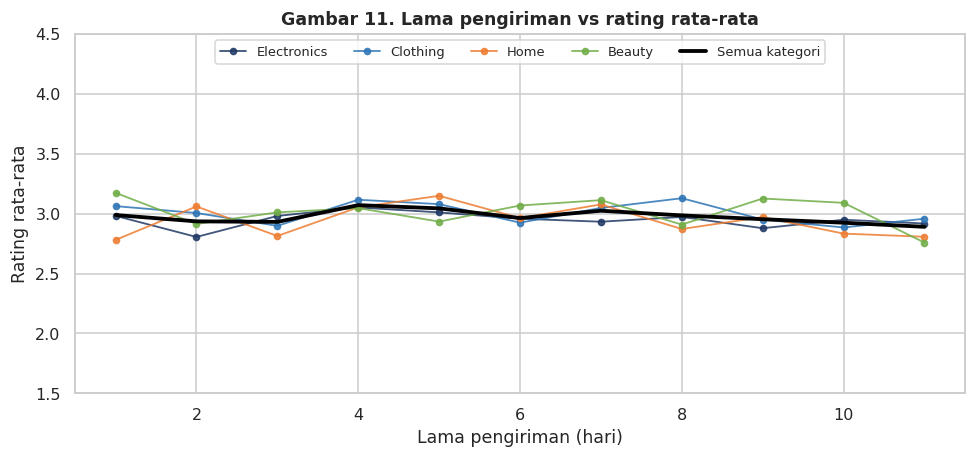

In [18]:
# FIG: fig11_pengiriman_rating
dr = df.groupby(['delivery_days', 'product_category'], observed=True).customer_rating.mean().unstack()
fig, ax = plt.subplots(figsize=(9, 4.3))
for c in CATS: ax.plot(dr.index, dr[c], marker='o', ms=4, lw=1.2, color=COL[c], label=c, alpha=.85)
ov = df.groupby('delivery_days').customer_rating.mean()
ax.plot(ov.index, ov.values, color='black', lw=2.5, label='Semua kategori')
ax.set_ylim(1.5, 4.5); ax.set_xlabel('Lama pengiriman (hari)'); ax.set_ylabel('Rating rata-rata'); ax.legend(ncol=5, fontsize=8.5, loc='upper center')
ax.set_title('Gambar 11. Lama pengiriman vs rating rata-rata', fontweight='bold'); plt.tight_layout(); plt.show()
rows = []
for c, x in list(df.groupby('product_category', observed=True)) + [('ALL', df)]:
    r, p = stats.pearsonr(x.delivery_days, x.customer_rating); rows.append([c, r, p])
dl_tbl = pd.DataFrame(rows, columns=['category', 'r_delivery_rating', 'p_value'])
print(dl_tbl.to_string(index=False))
fast, slow = df[df.delivery_days <= 3].customer_rating, df[df.delivery_days >= 9].customer_rating
t, pt = stats.ttest_ind(fast, slow, equal_var=False)
print(f'\nRating pengiriman <=3 hari: {fast.mean():.2f} (n={len(fast)}) | >=9 hari: {slow.mean():.2f} (n={len(slow)}) | uji-t p={pt:.3f}')
print(f'Rating >=4: {(df.customer_rating>=4).mean():.1%} | Rating <=2: {(df.customer_rating<=2).mean():.1%}')

## F. Analisis Tren Waktu
Data membentang 2022 - 9 Sep 2035, dan **65,3% order bertanggal setelah 30 Sep 2026** (sudah ditandai `is_future_date`). Tren tahunan memakai tahun penuh 2022-2034; 2035 tidak lengkap sehingga dikeluarkan. Hasil diuji ulang hanya dengan data <= 30 Sep 2026 sebagai uji sensitivitas.

product_category  Electronics  Clothing   Home  Beauty
year                                                  
2022                  131.800   106.900 78.600  54.500
2023                  124.800    98.500 85.900  56.700
2024                  132.400   102.300 75.100  53.400
2025                  133.200   101.300 74.500  40.800
2026                  129.400   131.000 77.700  48.300
2027                  131.800   116.000 75.300  63.000
2028                  146.300   108.900 71.200  50.400
2029                  122.500   112.000 59.900  64.800
2030                  151.500   104.000 76.700  55.700
2031                  135.500   119.400 68.300  42.100
2032                  125.900   126.400 71.100  63.200
2033                  157.300   105.300 67.700  78.500
2034                  126.300   115.300 55.300  66.300

YoY (%):
product_category  Electronics  Clothing    Home  Beauty
year                                                   
2023                   -5.300    -7.800   9.200   4.0

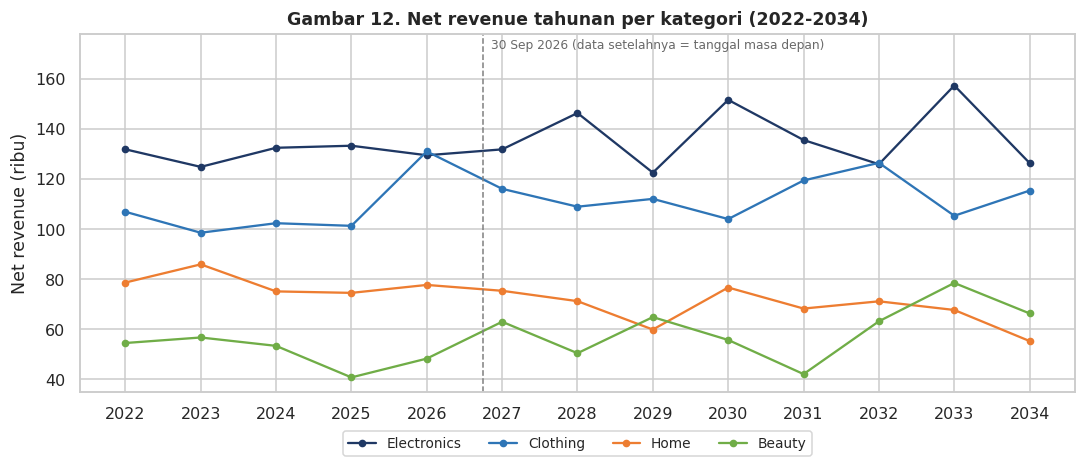

In [19]:
# FIG: fig12_tren_tahunan
full = df[df.year <= 2034]
pivot = full.groupby(['year', 'product_category'], observed=True).revenue.sum().unstack()[CATS]
yoy = pivot.pct_change().iloc[1:]
fig, ax = plt.subplots(figsize=(10, 4.4))
for c in CATS: ax.plot(pivot.index, pivot[c] / 1e3, marker='o', ms=4, color=COL[c], label=c)
ax.set_ylim(35, 178); ax.axvline(2026.75, ls='--', color='grey', lw=1); ax.text(2026.85, 176, '30 Sep 2026 (data setelahnya = tanggal masa depan)', fontsize=8, va='top', color='dimgrey')
ax.set_xticks(pivot.index); ax.set_ylabel('Net revenue (ribu)'); ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(.5, -.09), fontsize=9)
ax.set_title('Gambar 12. Net revenue tahunan per kategori (2022-2034)', fontweight='bold'); plt.tight_layout(); plt.show()
print((pivot / 1e3).round(1).to_string())
print('\nYoY (%):'); print((yoy * 100).round(1).to_string())
print('\nRata-rata YoY (%) :', (yoy.mean() * 100).round(1).to_dict())
print('Simpangan baku YoY:', (yoy.std() * 100).round(1).to_dict())

In [20]:
valid = df[df.is_future_date == 0]
share_all   = df.groupby('product_category', observed=True).revenue.sum() / df.revenue.sum()
share_valid = valid.groupby('product_category', observed=True).revenue.sum() / valid.revenue.sum()
drate_all   = df.groupby('product_category', observed=True).discount_value.sum() / df.groupby('product_category', observed=True).gross_sales.sum()
drate_valid = valid.groupby('product_category', observed=True).discount_value.sum() / valid.groupby('product_category', observed=True).gross_sales.sum()
sens = pd.DataFrame({'share_all': share_all, 'share_valid_only': share_valid, 'disc_rate_all': drate_all, 'disc_rate_valid_only': drate_valid})
print(f'Baris valid (<= 30 Sep 2026): {len(valid):,} dari {len(df):,}')
print(sens.to_string())
r_v, p_v = stats.pearsonr(valid.discount, valid.quantity)
print(f'\nKorelasi diskon-quantity (data valid saja): r={r_v:.3f}, p={p_v:.3f}')

Baris valid (<= 30 Sep 2026): 1,734 dari 5,000
                  share_all  share_valid_only  disc_rate_all  disc_rate_valid_only
product_category                                                                  
Electronics           0.358             0.358          0.177                 0.173
Clothing              0.300             0.286          0.188                 0.189
Home                  0.192             0.215          0.179                 0.181
Beauty                0.150             0.141          0.179                 0.189

Korelasi diskon-quantity (data valid saja): r=0.014, p=0.561


## G. Segmentasi Pendukung (konteks)
Region dan payment method hanya sebagai konteks (di luar scope ranking wilayah).

                 net  rating  delivery  orders  share
region                                               
East   1,236,044.230   2.973     6.104    1227  0.242
North  1,281,508.450   2.993     6.118    1276  0.251
South  1,246,640.900   2.968     6.173    1208  0.244
West   1,345,582.160   2.962     6.082    1289  0.263

Selisih net revenue region tertinggi vs terendah: 8.9%


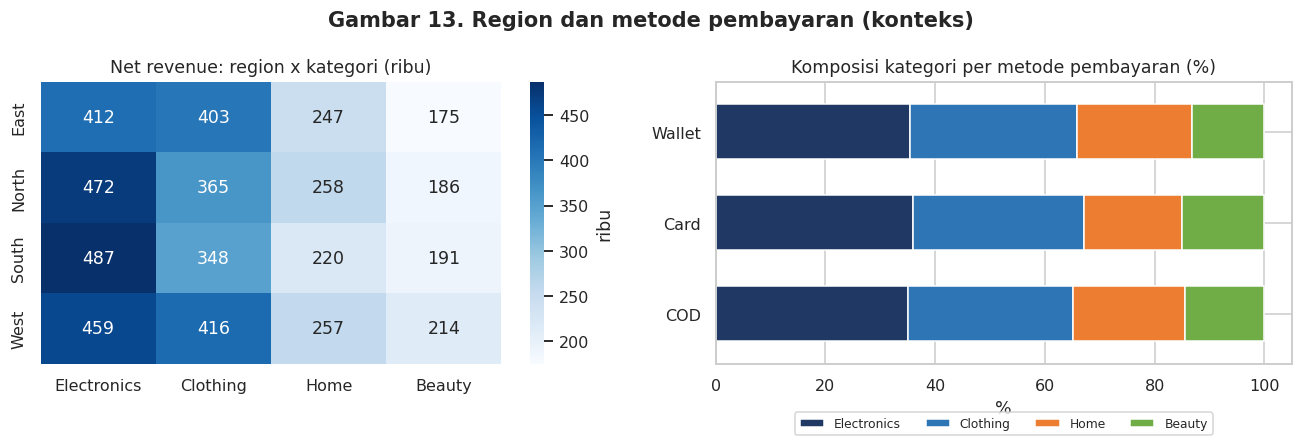

In [21]:
# FIG: fig13_region_pembayaran
rc = df.groupby(['region', 'product_category'], observed=True).revenue.sum().unstack()[CATS]
pc = pd.crosstab(df.payment_method, df.product_category, normalize='index')[CATS] * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.heatmap(rc / 1e3, annot=True, fmt='.0f', cmap='Blues', ax=axes[0], cbar_kws={'label': 'ribu'})
axes[0].set_title('Net revenue: region x kategori (ribu)'); axes[0].set_xlabel(''); axes[0].set_ylabel('')
pc.plot(kind='barh', stacked=True, ax=axes[1], color=[COL[c] for c in CATS], width=.6)
axes[1].set_title('Komposisi kategori per metode pembayaran (%)'); axes[1].set_xlabel('%'); axes[1].set_ylabel('')
axes[1].legend(ncol=4, fontsize=8, loc='upper center', bbox_to_anchor=(.5, -.15))
fig.suptitle('Gambar 13. Region dan metode pembayaran (konteks)', fontweight='bold'); fig.tight_layout(); plt.show()
reg = df.groupby('region').agg(net=('revenue', 'sum'), rating=('customer_rating', 'mean'), delivery=('delivery_days', 'mean'), orders=('order_id', 'count'))
reg['share'] = reg.net / TOTAL_NET
print(reg.to_string())
print('\nSelisih net revenue region tertinggi vs terendah:', f"{reg.net.max()/reg.net.min()-1:.1%}")

ANOVA rating antar kategori   : p=0.353
ANOVA pengiriman antar kategori: p=0.803


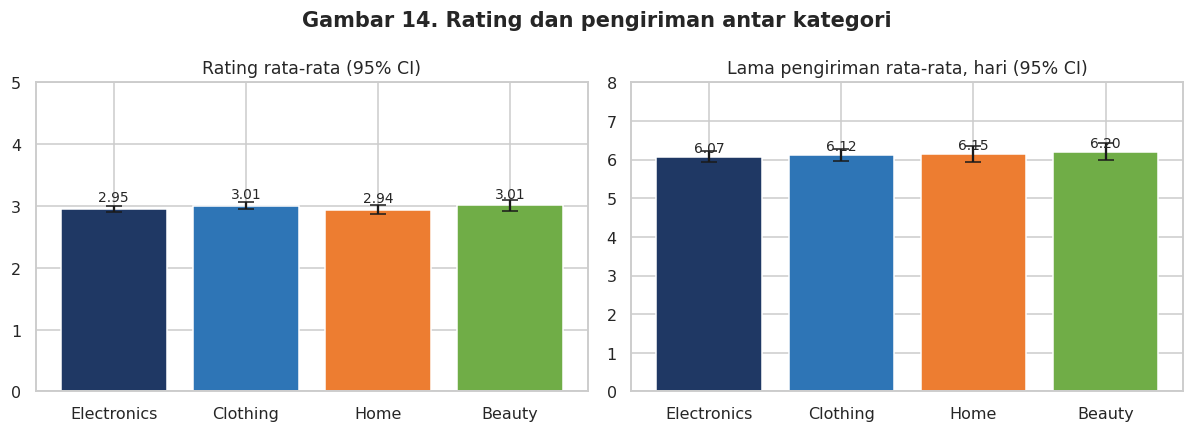

In [22]:
# FIG: fig14_rating_pengiriman_ci
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, ttl, lim in [(axes[0], 'customer_rating', 'Rating rata-rata (95% CI)', (0, 5)), (axes[1], 'delivery_days', 'Lama pengiriman rata-rata, hari (95% CI)', (0, 8))]:
    m = df.groupby('product_category', observed=True)[col].agg(['mean', 'sem']).reindex(CATS)
    ax.bar(m.index, m['mean'], yerr=1.96 * m['sem'], capsize=5, color=[COL[c] for c in CATS])
    for i, v in enumerate(m['mean']): ax.text(i, v + 0.12, f'{v:.2f}', ha='center', fontsize=9)
    ax.set_ylim(*lim); ax.set_title(ttl)
fig.suptitle('Gambar 14. Rating dan pengiriman antar kategori', fontweight='bold'); fig.tight_layout(); plt.show()
f1, p1 = stats.f_oneway(*[x.customer_rating for _, x in df.groupby('product_category', observed=True)])
f2, p2 = stats.f_oneway(*[x.delivery_days for _, x in df.groupby('product_category', observed=True)])
print(f'ANOVA rating antar kategori   : p={p1:.3f}')
print(f'ANOVA pengiriman antar kategori: p={p2:.3f}')

In [23]:
out = df[df.is_revenue_outlier == 1]
out_share = out.revenue.sum() / TOTAL_NET
print(f'Order outlier revenue: {len(out)} ({len(out)/len(df):.1%} order) menyumbang {out_share:.1%} net revenue')
print(out.product_category.value_counts().to_string())
print()
print(df.nlargest(5, 'revenue')[['order_id', 'product_category', 'quantity', 'unit_price', 'discount', 'revenue']].to_string(index=False))
cust = df.customer_id.value_counts()
print(f'\nCustomer unik {cust.size}; order per customer: rata-rata {cust.mean():.1f}, min {cust.min()}, maks {cust.max()}')

Order outlier revenue: 67 (1.3% order) menyumbang 4.6% net revenue
product_category
Electronics    26
Clothing       17
Home           14
Beauty         10

 order_id product_category  quantity  unit_price  discount   revenue
    10810      Electronics         7     594.420     0.010 4,119.330
    14884      Electronics         7     583.310     0.000 4,083.170
    12215      Electronics         7     591.150     0.020 4,055.290
    13102           Beauty         7     596.120     0.040 4,005.930
    13687         Clothing         7     578.590     0.030 3,928.630

Customer unik 989; order per customer: rata-rata 5.1, min 1, maks 14


## H. Ringkasan: 10 Insight dan 3 Temuan Utama

### 10 Insight
1. **Electronics dan Clothing menguasai penjualan.** Electronics menyumbang 35,8% net revenue (1.829.899) dan Clothing 30,0%; keduanya bersama 65,8%. Home 19,2% dan Beauty 15,0%.
2. **Kontribusi ditentukan jumlah order, bukan harga.** Porsi order tiap kategori (Electronics 35,5%, Clothing 30,6%, Home 19,4%, Beauty 14,5%) hampir sama dengan porsi revenue. Harga satuan rata-rata nyaris seragam (304-315; ANOVA p=0,25, tidak berbeda nyata).
3. **Beauty kecil tetapi nilai per order tertinggi.** Beauty hanya 15,0% dari revenue (723 order), namun AOV-nya 1.059 vs 1.001-1.030 kategori lain. Selisihnya kecil (sekitar 4%), jadi peluang ada pada menambah volume order, bukan menaikkan harga.
4. **Diskon menggerus 1.130.246 (18,1% dari gross sales).** Tingkat diskon per kategori hampir sama: Electronics terendah (17,7%) dan Clothing tertinggi (18,8%). Nilai diskon terbesar ada di Electronics (393.413) karena skala penjualannya.
5. **Diskon lebih besar tidak menambah volume.** Rata-rata quantity per order stabil di 3,95-4,10 pada semua kelompok diskon; korelasi diskon-quantity r=-0,004 (p=0,76, tidak signifikan). Tidak ditemukan titik di mana diskon 'mulai sebanding' karena tidak ada tambahan volume pada level diskon mana pun.
6. **Akibatnya nilai per order turun tajam.** AOV turun dari 1.208 (diskon 0-5%) menjadi 841 (diskon >30-35%), yaitu turun 30,4% dengan quantity yang sama. Order berdiskon >20% menyumbang 68,2% dari seluruh nilai diskon.
7. **Diskon dan harga tidak berkaitan dengan rating.** Korelasi diskon-rating r=0,013 (p=0,37); harga-rating r=0,005; harga-quantity r=0,001 (p=0,92). Rating rata-rata 2,97 dan hanya 25,4% order berating >=4, sedangkan 26,9% berating <=2, sama rendahnya di semua kategori.
8. **Lama pengiriman tidak berkaitan dengan rating.** r=-0,018 (p=0,21); di tiap kategori |r| < 0,03. Order dengan pengiriman cepat (<=3 hari) dan lambat (>=9 hari) berating serupa. Jadi rating rendah bukan disebabkan kecepatan pengiriman dan penyebabnya perlu dicari di luar data ini.
9. **Profit sangat sensitif terhadap rasio biaya dan diskon.** Pada biaya 60% margin 26,7% dan tidak ada order merugi; pada 70% margin 14,5% dengan titik impas diskon 30%, sehingga 13,9% order merugi; pada 80% margin tinggal 2,3% dan 44,0% order merugi. Electronics margin tertinggi di semua skenario (15,0% pada biaya 70%) dan Clothing terendah (13,8%), hanya karena diskon Clothing sedikit lebih tinggi.
10. **Tren tahunan berfluktuasi tanpa arah pertumbuhan yang jelas.** YoY tiap kategori naik-turun (simpangan baku 13-25 poin persen; paling bergejolak: Beauty). Peringkat kategori dan tingkat diskon tidak berubah bila hanya memakai data <= 30 Sep 2026 (porsi Electronics 35,8% vs 35,8% pada seluruh data). Region dan metode pembayaran juga seragam (selisih revenue region tertinggi-terendah 8,9%); 67 order outlier (1,3%) menyumbang 4,6% revenue.

### 3 Temuan Utama
**Temuan 1 - Penjualan terkonsentrasi pada Electronics dan Clothing (65,8% net revenue), digerakkan volume order, bukan harga.** Harga, AOV dan diskon antar kategori hampir seragam sehingga pembeda utamanya adalah jumlah order. Beauty (15,0%) dan Home (19,2%) kecil karena order-nya sedikit.

**Temuan 2 - Diskon 18,1% dari gross sales (1.130.246) tidak terbukti menambah volume maupun rating.** Quantity per order tetap sekitar 4 unit pada diskon 0% sampai 35%, sehingga diskon hanya memangkas nilai per order (AOV turun 30,4% dari kelompok diskon terendah ke tertinggi).

**Temuan 3 - Profitabilitas ditentukan oleh disiplin diskon: risiko merugi muncul bila biaya >= 70% dari harga jual.** Titik impas diskon = 1 - rasio biaya. Pada biaya 70%, 13,9% order merugi (kerugian estimasi 24.675); pada biaya 80%, 44,0% order merugi dan margin hanya 2,3%. Rasio biaya sebenarnya perlu dikonfirmasi Finance.

### Keterbatasan Data
- Tidak ada data biaya produk: profit hanya skenario (biaya 60/70/80% dari gross sales) dan diasumsikan sama untuk semua kategori.
- 3.266 order (65,3%) bertanggal setelah 30 Sep 2026 (sampai 9 Sep 2035). Baris dipertahankan dan ditandai; kesimpulan kategori/diskon tidak berubah pada uji sensitivitas. tetapi analisis tren waktu harus dibaca hati-hati.
- Sebaran harga, diskon, rating dan pengiriman hampir merata (uniform) dan hubungan antarvariabel mendekati nol. Pola ini khas data simulasi, sehingga 'tidak ada hubungan' adalah temuan yang jujur, bukan kegagalan analisis.
- Korelasi tidak membuktikan sebab-akibat. Tanpa data kompetitor, stok, atau kampanye, efek diskon terhadap volume hanya bisa dinilai secara observasional.
- Rating dan pengiriman hanya dilihat di level order; tidak ada data retur, pembatalan, atau ulasan teks.

